In [1]:
!/home/ubuntu/LLM-integrated-Quantum-compiler/satmapenv/bin/pip install matplotlib -q 2>/dev/null || true

# Conversation to Compilation: LLM-Driven Quantum Compiler Synthesis

![](images/compiler-flow-diagram.png)

## Set the project root path

In [2]:
ROOT = "/home/ubuntu/LLM-integrated-Quantum-compiler"

## Imports for Hugging Face, transformers, and JSON

In [3]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
import sys
import json
import random


## Visualize the sample Input circuit

In [4]:
circuit_path = os.path.join(
    ROOT, "asplos-2026", "sample-input-files", "sample-circuit.qasm"
)
try:
    from qiskit import QuantumCircuit
    qc = QuantumCircuit.from_qasm_file(circuit_path)
    print(qc.draw(output="text", fold=-1))
except Exception:
    with open(circuit_path) as f:
        print(f.read())

                                                                      
 q_0: ────────────────────────────────────────────────────────────────
           ┌───┐                    ┌──────────┐                      
 q_1: ─────┤ X ├────────────────────┤1         ├──■────■──────────────
      ┌───┐└─┬─┘┌───┐               │          │  │    │              
 q_2: ┤ H ├──┼──┤ X ├───────────────┤          ├──┼────┼──────────────
      └───┘  │  └─┬─┘               │          │  │    │              
 q_3: ───────┼────┼────■─────────■──┤          ├──┼────┼──────────────
             │    │    │         │  │          │  │    │              
 q_4: ───────┼────■────┼─────────┼──┤          ├──┼────┼──────────────
             │    │    │         │  │          │  │    │  ┌──────────┐
 q_5: ──■────┼────┼────┼─────────┼──┤          ├──┼────┼──┤1         ├
        │    │    │    │  ┌───┐  │  │          │  │  ┌─┴─┐│          │
 q_6: ──┼────┼────┼────■──┤ X ├──┼──┤0 custom4 ├──┼──┤ X ├┤0         ├
      

## Generate a hardware topology

Start with a rectangular grid of qubits (rows x cols) connected by horizontal and
vertical edges. Then optionally add diagonal edges to selected grid cells:
a triangle adds one diagonal, a fully connected cell adds both diagonals (connecting
all four corners of that cell).

In [5]:
def generate_hardware_map(
    rows,
    cols,
    num_extra_single_diagonal=0,
    num_extra_fully_connected=0,
    seed=None,
):
   
    if rows < 2:
        raise ValueError(f"Need at least 2 rows, got {rows}.")
    if cols < 2:
        raise ValueError(f"Need at least 2 columns, got {cols}.")
    if num_extra_single_diagonal < 0:
        raise ValueError("num_extra_single_diagonal cannot be negative.")
    if num_extra_fully_connected < 0:
        raise ValueError("num_extra_fully_connected cannot be negative.")
    if seed is not None:
        random.seed(seed)

    num_qubits = rows * cols

    def idx(r, c):
        return r * cols + c

    edges = set()

    # Base grid: horizontal and vertical edges
    for r in range(rows):
        for c in range(cols):
            if c + 1 < cols:
                edges.add((idx(r, c), idx(r, c + 1)))
            if r + 1 < rows:
                edges.add((idx(r, c), idx(r + 1, c)))

    # Each grid cell is defined by its top-left corner (r, c)
    all_cells = [(r, c) for r in range(rows - 1) for c in range(cols - 1)]
    total_extras = num_extra_single_diagonal + num_extra_fully_connected

    if total_extras > len(all_cells):
        raise ValueError(
            f"Only {len(all_cells)} grid cells available but "
            f"{total_extras} extras requested ({num_extra_single_diagonal} single diagonal "
            f"+ {num_extra_fully_connected} fully connected). Reduce the counts or increase grid size."
        )

    random.shuffle(all_cells)

    # Single diagonal cells: add one diagonal per cell
    for i in range(num_extra_single_diagonal):
        r, c = all_cells[i]
        a, b = idx(r, c), idx(r + 1, c + 1)
        edges.add((min(a, b), max(a, b)))

    # Fully connected cells: add both diagonals (all 4 corners connected)
    for i in range(num_extra_single_diagonal, total_extras):
        r, c = all_cells[i]
        a, b = idx(r, c), idx(r + 1, c + 1)
        edges.add((min(a, b), max(a, b)))
        a, b = idx(r, c + 1), idx(r + 1, c)
        edges.add((min(a, b), max(a, b)))

    edge_list = sorted(edges)

    spec = {
        "num_physical_qubits": num_qubits,
        "edges": [list(e) for e in edge_list],
    }

    out_path = os.path.join(
        ROOT, "asplos-2026", "sample-input-files", "generated-hardware.json"
    )
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(spec, f, indent=2)

    print(f"Saved to: {out_path}")
    print(f"  Grid            : {rows} x {cols}  ({num_qubits} qubits)")
    print(f"  Base grid edges : {(rows - 1) * cols + rows * (cols - 1)}")
    print(f"  Single diagonal : {num_extra_single_diagonal}")
    print(f"  Extra fully conn: {num_extra_fully_connected}")
    print(f"  Total edges     : {len(edge_list)}")

    return spec, out_path


hardware_spec, hardware_edges_path = generate_hardware_map(
    rows=4,
    cols=5,
    num_extra_single_diagonal=3,
    num_extra_fully_connected=2,
    seed=42,
)

Saved to: /home/ubuntu/LLM-integrated-Quantum-compiler/asplos-2026/sample-input-files/generated-hardware.json
  Grid            : 4 x 5  (20 qubits)
  Base grid edges : 31
  Single diagonal : 3
  Extra fully conn: 2
  Total edges     : 38


## Visualize the hardware topology

Draw the generated coupling map to verify shape placement and overall connectivity
before running the compiler.

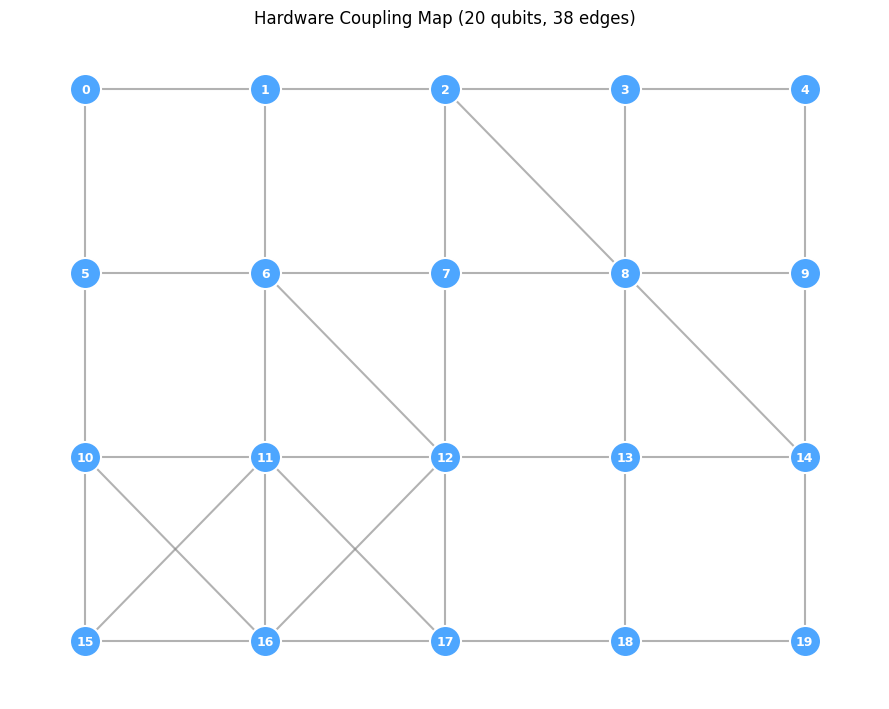

In [6]:
import matplotlib.pyplot as plt
import networkx as nx


def visualize_hardware(spec, rows, cols):
    G = nx.Graph()
    G.add_nodes_from(range(spec["num_physical_qubits"]))
    G.add_edges_from([tuple(e) for e in spec["edges"]])

    # Place nodes on a grid (row 0 at top, col 0 at left)
    pos = {}
    for node in range(rows * cols):
        r = node // cols
        c = node % cols
        pos[node] = (c, -r)

    plt.figure(figsize=(cols * 1.8, rows * 1.8))
    nx.draw_networkx_edges(G, pos, alpha=0.6, width=1.5, edge_color="gray")
    nx.draw_networkx_nodes(G, pos, node_color="#4DA6FF", node_size=500,
                           edgecolors="white", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold")
    plt.title(f"Hardware Coupling Map ({spec['num_physical_qubits']} qubits, {G.number_of_edges()} edges)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


visualize_hardware(hardware_spec, rows=4, cols=5)

## Load the fine-tuned LLM

In [7]:
# load_dotenv()
# login(token=os.environ.get("HF_TOKEN"))

modelId = "rvinay73/gate-shape-compiler"
local_model_path = os.path.join(ROOT, "asplos-2026", "local_model")  # or any fixed path

config_path = os.path.join(local_model_path, "config.json")

# Check if the model is already downloaded locally
if os.path.isfile(config_path):
    print(f"Loading model and tokenizer from local path: {local_model_path}")
    tokenizer = AutoTokenizer.from_pretrained(local_model_path)
    model = AutoModelForCausalLM.from_pretrained(local_model_path, device_map="cuda", torch_dtype="auto").eval()
    print(f"Model loaded from local path")
else:
    print(f"Downloading model and tokenizer from Hugging Face and saving to {local_model_path}")
    tokenizer = AutoTokenizer.from_pretrained(modelId, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(modelId, device_map="auto", torch_dtype="auto").eval()
    
    os.makedirs(local_model_path, exist_ok=True)
    tokenizer.save_pretrained(local_model_path)
    model.save_pretrained(local_model_path)
    print("Model and tokenizer saved locally.")



Loading model and tokenizer from local path: /home/ubuntu/LLM-integrated-Quantum-compiler/asplos-2026/local_model
Model loaded from local path


## Natural language constraints

- Describe how multi-qubit gates should be laid out
- Example: 3-qubit gates in a line, 4-qubit gates in a square
- LLM turns this into JSON rules with `nQubits`, `shape`, and `edges` (connectivity pattern between qubits)

In [8]:
sys.path.insert(0, os.path.join(ROOT, "scripts"))

from prompt_utils import build_prompt

userInput = "My 3 qubit gates should be in a line. My 4 qubit gates should be in a full connected section."
prompt = build_prompt(userInput)

messages = [{"role": "user", "content": prompt}]

In [9]:

enc = tokenizer.apply_chat_template(
    conversation=messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
)


enc = enc.to(model.device)


out = model.generate(**enc, max_new_tokens=80)


promptLen = enc["input_ids"].size(-1)

response = tokenizer.decode(out[0][promptLen:], skip_special_tokens=True)


s = response
try:
    parsed = json.loads(s)
    print(json.dumps(parsed, indent=3))
except json.JSONDecodeError:
    print(s) 

{
   "rules": [
      {
         "nQubits": 3,
         "shape": "line",
         "edges": [
            [
               0,
               1
            ],
            [
               1,
               2
            ]
         ]
      },
      {
         "nQubits": 4,
         "shape": "clique",
         "edges": [
            [
               0,
               1
            ],
            [
               0,
               2
            ],
            [
               0,
               3
            ],
            [
               1,
               2
            ],
            [
               1,
               3
            ],
            [
               2,
               3
            ]
         ]
      }
   ]
}


## Validate the LLM output

Before passing the LLM response to the subgraph matcher, verify that the JSON
conforms to the expected schema. The checker looks for correct top-level structure,
required keys in each rule, valid data types, sensible edge indices, and graph
connectivity within each shape.

In [10]:
def validate_llm_output(data):
    
    errors = []

    if not isinstance(data, dict):
        errors.append("Top-level value must be a JSON object.")
        return errors

    if "rules" not in data:
        errors.append("Missing required key 'rules'.")
        return errors

    rules = data["rules"]
    if not isinstance(rules, list):
        errors.append("'rules' must be a list.")
        return errors

    if len(rules) == 0:
        errors.append("'rules' is empty; expected at least one rule.")
        return errors

    for idx, rule in enumerate(rules):
        tag = f"Rule {idx}"

        if not isinstance(rule, dict):
            errors.append(f"{tag}: expected a JSON object, got {type(rule).__name__}.")
            continue

        required_keys = {"nQubits", "shape", "edges"}
        missing = required_keys - set(rule.keys())
        if missing:
            errors.append(f"{tag}: missing key(s) {', '.join(sorted(missing))}.")
            continue

        n = rule["nQubits"]
        if not isinstance(n, int) or n < 2:
            errors.append(f"{tag}: 'nQubits' must be an integer >= 2, got {n!r}.")
            continue

        shape = rule["shape"]
        if not isinstance(shape, str) or not shape.strip():
            errors.append(f"{tag}: 'shape' must be a non-empty string.")

        edge_list = rule["edges"]
        if not isinstance(edge_list, list):
            errors.append(f"{tag}: 'edges' must be a list of [u, v] pairs.")
            continue

        edge_errors = False
        seen = set()
        for j, edge in enumerate(edge_list):
            if not isinstance(edge, (list, tuple)) or len(edge) != 2:
                errors.append(f"{tag}, edge {j}: expected a pair [u, v].")
                edge_errors = True
                continue
            u, v = edge
            if not isinstance(u, int) or not isinstance(v, int):
                errors.append(f"{tag}, edge {j}: qubit indices must be integers.")
                edge_errors = True
                continue
            if u < 0 or u >= n or v < 0 or v >= n:
                errors.append(
                    f"{tag}, edge {j}: index out of range 0..{n-1}, got [{u}, {v}]."
                )
                edge_errors = True
            if u == v:
                errors.append(f"{tag}, edge {j}: self-loop [{u}, {v}] is not allowed.")
                edge_errors = True
            canonical = (min(u, v), max(u, v))
            if canonical in seen:
                errors.append(f"{tag}, edge {j}: duplicate edge [{u}, {v}].")
            seen.add(canonical)

        # Only check connectivity if individual edges were all valid
        if not edge_errors and len(edge_list) > 0:
            G_check = nx.Graph()
            G_check.add_nodes_from(range(n))
            for e in edge_list:
                G_check.add_edge(e[0], e[1])
            if not nx.is_connected(G_check):
                errors.append(f"{tag}: the described shape is not a connected graph.")

    return errors


# Run validation
try:
    llm_output = json.loads(response)
except json.JSONDecodeError as e:
    raise ValueError(
        f"LLM returned invalid JSON.\n  Parse error: {e}\n  Raw output: {response}"
    )

issues = validate_llm_output(llm_output)

if issues:
    print(f"Validation found {len(issues)} problem(s):")
    for issue in issues:
        print(f"  - {issue}")
    raise ValueError(
        "LLM output does not match the expected schema. See details above."
    )

print("All checks passed. LLM output is valid.")
print(json.dumps(llm_output, indent=2))

All checks passed. LLM output is valid.
{
  "rules": [
    {
      "nQubits": 3,
      "shape": "line",
      "edges": [
        [
          0,
          1
        ],
        [
          1,
          2
        ]
      ]
    },
    {
      "nQubits": 4,
      "shape": "clique",
      "edges": [
        [
          0,
          1
        ],
        [
          0,
          2
        ],
        [
          0,
          3
        ],
        [
          1,
          2
        ],
        [
          1,
          3
        ],
        [
          2,
          3
        ]
      ]
    }
  ]
}


## Pattern matcher

- Takes LLM rules and hardware graph (raw edges)
- Finds all places where each gate shape can fit on the hardware
- Writes a target spec
- Spec lists which physical qubits each gate type can use

In [11]:
sys.path.insert(0, os.path.join(ROOT, "scripts"))
from build_arch_from_llm_rules import load_raw_hardware, load_llm_rules, build_target_spec


llm_data = json.loads(response)
llm_rules = load_llm_rules(llm_data)

# Raw hardware: path to edges-only JSON
raw_path = hardware_edges_path
raw_spec = load_raw_hardware(raw_path)

target_spec = build_target_spec(raw_spec, llm_rules)

# Save target hardware spec to a JSON file
out_path = os.path.join(ROOT, "asplos-2026", "sample-output-files", "arch_from_llm.json")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w") as f:
    json.dump(target_spec, f, indent=2)
print("Wrote", out_path)

Wrote /home/ubuntu/LLM-integrated-Quantum-compiler/asplos-2026/sample-output-files/arch_from_llm.json


## Visualize subgraph matches on hardware

Highlight the physical qubits that participate in at least one valid placement
for each gate type. Each colour represents a different gate shape, and the legend
reports the total number of placements found.

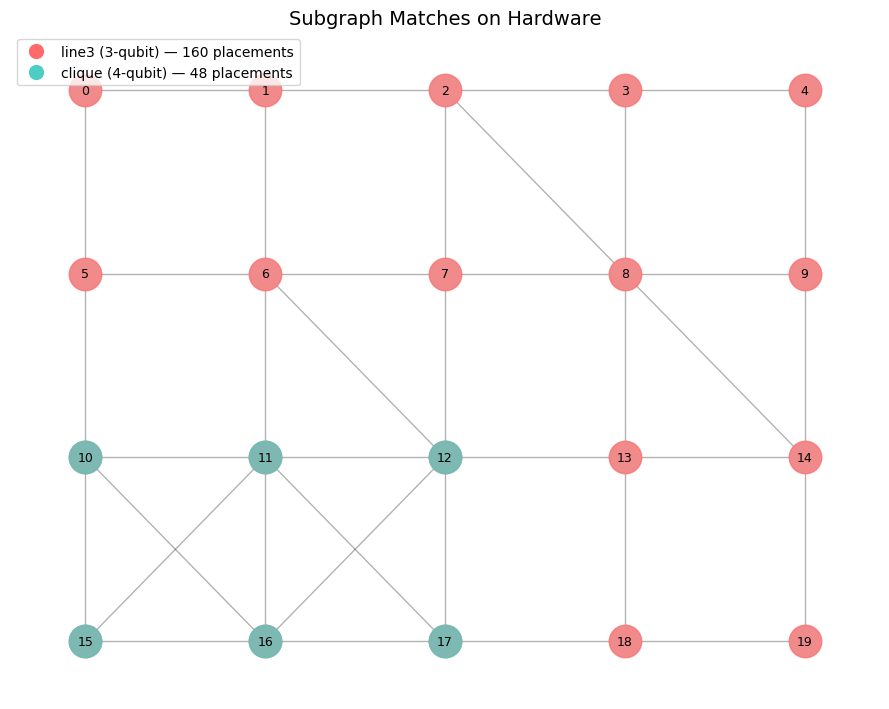

In [12]:
def visualize_subgraph_matches(spec, rows, cols):
    
    G = nx.Graph()
    n = spec["num_physical_qubits"]
    G.add_nodes_from(range(n))
    G.add_edges_from([tuple(e) for e in spec["edges"]])

    pos = {}
    for node in range(rows * cols):
        r = node // cols
        c = node % cols
        pos[node] = (c, -r)

    matches = spec.get("subgraph_matches", {})
    palette = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7", "#DDA0DD"]

    fig, ax = plt.subplots(figsize=(cols * 1.8, rows * 1.8))
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color="lightgray", node_size=500, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

    handles = []
    ci = 0

    for gate_size in sorted(matches, key=int):
        if gate_size == "2":
            continue
        for type_name, match_list in matches[gate_size].items():
            if not match_list:
                continue
            color = palette[ci % len(palette)]
            involved = set()
            for m in match_list:
                involved.update(m)

            nx.draw_networkx_nodes(
                G, pos,
                nodelist=sorted(involved),
                node_color=color,
                node_size=550,
                alpha=0.7,
                ax=ax,
            )
            handles.append(
                plt.Line2D(
                    [0], [0], marker="o", color="w",
                    markerfacecolor=color, markersize=12,
                    label=f"{type_name} ({gate_size}-qubit) — {len(match_list)} placements",
                )
            )
            ci += 1

    if handles:
        ax.legend(handles=handles, loc="upper left", fontsize=10)
    else:
        print("No subgraph matches with arity > 2 found.")

    ax.set_title("Subgraph Matches on Hardware", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


visualize_subgraph_matches(target_spec, rows=4, cols=5)

## MaxSAT compiler

- Maps logical qubits to physical qubits
- Inserts SWAPs so every gate can run
- Takes circuit and hardware spec, outputs mapped circuit

**MaxSAT formulation for multi qubit gates**

For each n-qubit gate at step k with logical qubits q₁,…,qₙ, SubgraphMatches = allowed ordered n-tuples from the hardware spec. The constraint:
```
⋁_{M_j ∈ SubgraphMatches}  (  map(q₁,pⱼ₁,k) ∧ map(q₂,pⱼ₂,k) ∧ … ∧ map(qₙ,pⱼₙ,k)  )
```

Meaning: at least one tuple M_j must hold every logical qubit q_i , which maps to the corresponding physical qubit p_ji at step k.

In [13]:
sys.path.insert(0, os.path.join(ROOT, "src"))

import satmap
import hardware_spec as hw_spec

prog_path = os.path.join(ROOT, "asplos-2026", "sample-input-files", "sample-circuit.qasm")
hardware_spec_path = os.path.join(ROOT, "asplos-2026", "sample-output-files", "arch_from_llm.json")
out_path = os.path.join(ROOT, "asplos-2026", "sample-output-files", "output-circuit.qasm")
AUX_DIR = os.path.join(ROOT, "asplos-2026", "aux_files")

spec = hw_spec.load_spec(hardware_spec_path)
cm = hw_spec.build_cm_from_spec(spec)

os.makedirs(AUX_DIR, exist_ok=True)
base = os.path.splitext(os.path.basename(prog_path))[0]

os.chdir(ROOT)

stats, qasm = satmap.transpile(
    prog_path,
    cm,
    swapNum=1,
    cnfname=os.path.join(AUX_DIR, f"prob_{base}"),
    sname=os.path.join(AUX_DIR, f"sol_{base}"),
    slice_size=50,
    max_sat_time=28800,
    routing=True,
    bounded_above=True,
    hardware_spec=hardware_spec_path,
)

with open(out_path, "w") as f:
    f.write(qasm)
print("Wrote", out_path)

Wrote /home/ubuntu/LLM-integrated-Quantum-compiler/asplos-2026/sample-output-files/output-circuit.qasm


## Visualize the output circuit

In [14]:
from qiskit import QuantumCircuit as QC

qc_out = QC.from_qasm_str(qasm)
print(qc_out.draw(output="text", fold=-1))

                                                                         
 q_0: ───────■───────────────────────────────────────────────────────────
             │                                                           
 q_1: ───────■──────────────X────────────────────────────────────────────
             │              │                                            
 q_2: ───────┼──────────────┼────────────────────────────────────────────
             │              │                                            
 q_3: ───────┼──────────────┼────────────────────────────────────────────
      ┌───┐  │              │                                            
 q_4: ┤ H ├──┼──────────────┼────────────────────────────────────────────
      └───┘  │              │                                            
 q_5: ───────┼──────────────┼────────────────────────────────────────────
           ┌─┴─┐     ┌───┐  │                                            
 q_6: ─────┤ X ├─────┤ X ├──X─────────